# Partie 2 - KPI et Analyse RH

Objectif : transformer les donnees brutes en indicateurs RH exploitables pour la decision, avec un angle turnover, engagement, carriere, remuneration et mobilite interne.


In [14]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## 1. Tableau de bord KPI


In [15]:
kpi_table(df)


,KPI,Valeur
0,Effectif total,8020.00
1,Taux d'attrition (%),2.59
2,Score d'engagement moyen,68.15
3,Score de securite psychologique moyen,66.19
4,Taux de promotion sur 3 ans (%),24.64
5,Taux de mobilite interne (%),63.72
6,Heures de formation moyennes,34.64
7,Absenteisme moyen (jours),6.93
8,Heures supp. moyennes,19.55
9,Salaire moyen annuel,62313.28


## 2. Turnover

Le turnover global est faible, mais il est utile de l'observer selon plusieurs segments RH pour faire ressortir les zones de vigilance.


In [16]:
display(attrition_by_group(df, "department"))
display(attrition_by_group(df, "country"))
display(attrition_by_group(df, "manager_level", ascending=True))
display(attrition_by_group(df, "salary_quartile", ascending=True))


,department,effectif,departs,attrition_rate_pct
4,IT,970,28,2.89
0,Customer Support,1027,29,2.82
2,Finance,950,26,2.74
7,Sales,1005,27,2.69
3,HR,1036,27,2.61
5,Marketing,972,25,2.57
1,Data,1042,25,2.40
6,Operations,1018,21,2.06


,country,effectif,departs,attrition_rate_pct
1,France,1338,51,3.81
5,USA,1347,37,2.75
4,UK,1342,36,2.68
2,Germany,1356,36,2.65
0,Canada,1356,26,1.92
3,Spain,1281,22,1.72


,manager_level,effectif,departs,attrition_rate_pct
3,3,240,4,1.67
2,2,770,19,2.47
0,0,5229,134,2.56
1,1,1781,51,2.86


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,salary_quartile,effectif,departs,attrition_rate_pct
3,Q4,2005,44,2.19
1,Q2,2085,48,2.30
0,Q1,2005,55,2.74
2,Q3,1925,61,3.17


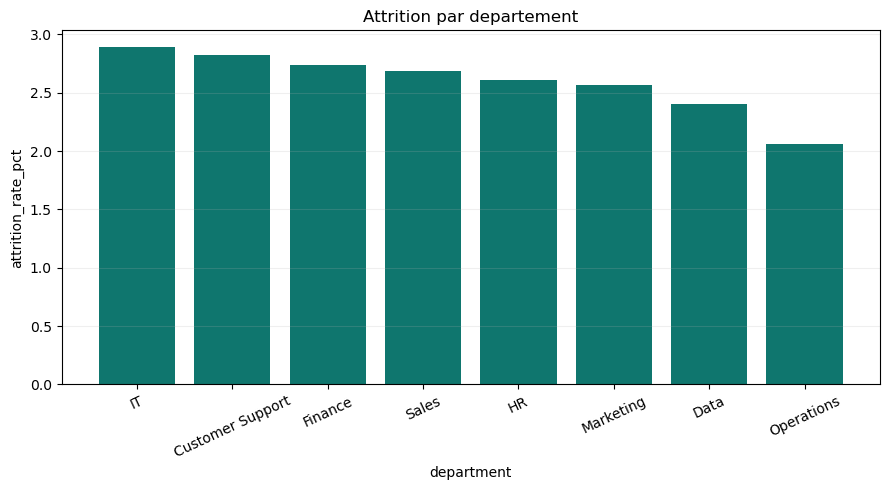

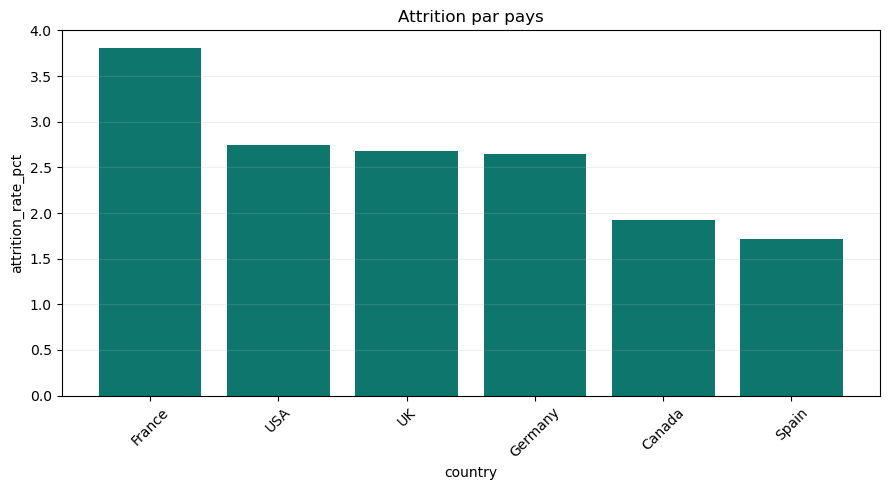

In [17]:
plot_bar(attrition_by_group(df, "department"), "department", "attrition_rate_pct", title="Attrition par departement", rotation=25)
plot_bar(attrition_by_group(df, "country"), "country", "attrition_rate_pct", title="Attrition par pays")


## 3. Engagement et conditions de travail

On relie ici l'engagement, la securite psychologique, l'absence et les heures supplementaires aux dynamiques de retention.


In [18]:
display(attrition_by_group(df, "engagement_band", ascending=True))
display(attrition_by_group(df, "overtime_band", ascending=True))
display(attrition_by_group(df, "absence_band", ascending=True))
display(average_by_group(df, "department", "engagement_score"))
display(average_by_group(df, "department", "psychological_safety_score"))


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,engagement_band,effectif,departs,attrition_rate_pct
3,Very High,1710,35,2.05
1,Medium,1973,49,2.48
2,High,1862,47,2.52
0,Low,2314,70,3.03
4,NaN,161,7,4.35


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,overtime_band,effectif,departs,attrition_rate_pct
1,6-15,1974,38,1.93
2,16-25,2523,67,2.66
0,0-5,1092,31,2.84
3,26+,2431,72,2.96


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,absence_band,effectif,departs,attrition_rate_pct
1,3-5,1670,37,2.22
0,0-2,1665,40,2.40
2,6-10,2861,73,2.55
3,11+,1824,58,3.18


,department,avg_engagement_score
0,Operations,69.62
1,HR,68.59
2,Sales,68.30
3,Customer Support,68.21
4,Finance,67.98
5,IT,67.81
6,Marketing,67.37
7,Data,67.24


,department,avg_psychological_safety_score
0,Data,66.56
1,IT,66.51
2,Sales,66.46
3,Marketing,66.21
4,HR,66.18
5,Operations,66.07
6,Finance,65.82
7,Customer Support,65.67


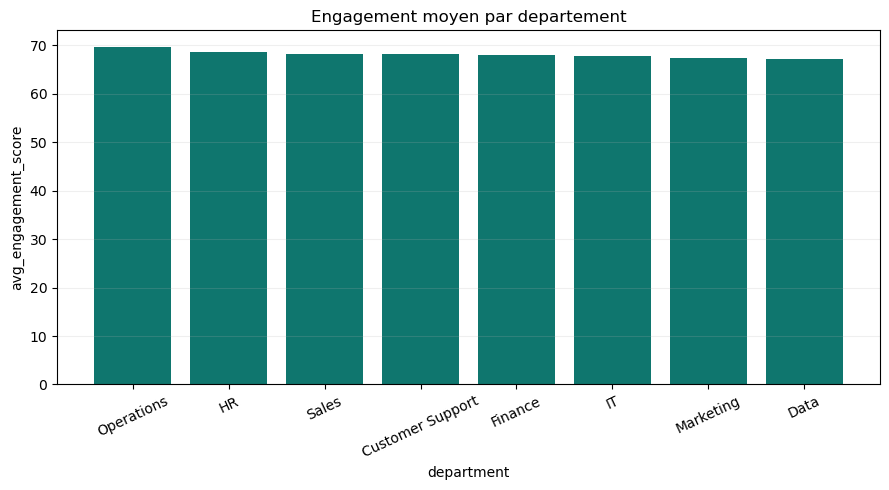

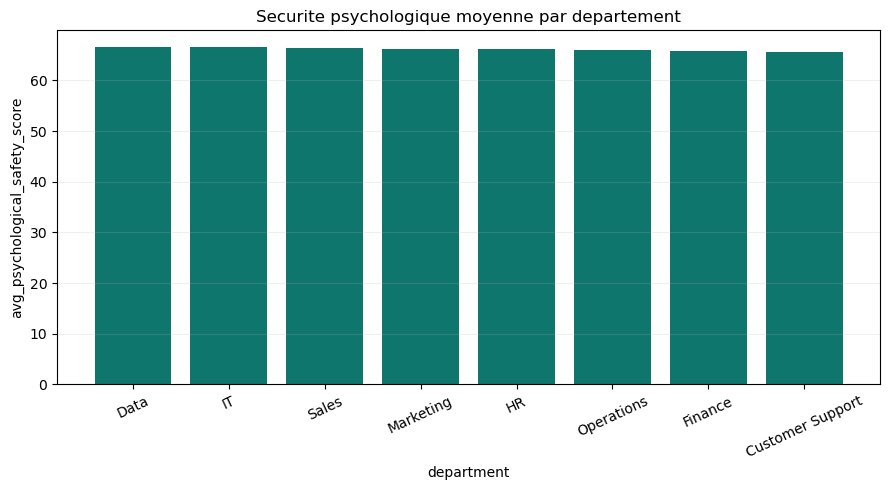

In [19]:
plot_bar(
    average_by_group(df, "department", "engagement_score"),
    "department",
    "avg_engagement_score",
    title="Engagement moyen par departement",
    rotation=25,
)
plot_bar(
    average_by_group(df, "department", "psychological_safety_score"),
    "department",
    "avg_psychological_safety_score",
    title="Securite psychologique moyenne par departement",
    rotation=25,
)


## 4. Evolution des carrieres


In [20]:
career_table = pd.DataFrame(
    {
        "promotion_rate_pct": df.groupby("department")["promotion_last_3y"].mean() * 100,
        "avg_training_hours": df.groupby("department")["training_hours"].mean(),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
    }
).round(2).sort_values("promotion_rate_pct", ascending=False)

career_table


,promotion_rate_pct,avg_training_hours,avg_internal_mobility
department,,,
Operations,26.13,33.31,1.04
Marketing,25.21,34.01,1.02
Data,24.86,35.59,1.02
Customer Support,24.73,34.74,1.07
IT,24.12,34.01,1.02
Sales,24.08,34.93,1.02
HR,24.03,35.89,0.95
Finance,23.89,34.58,0.95


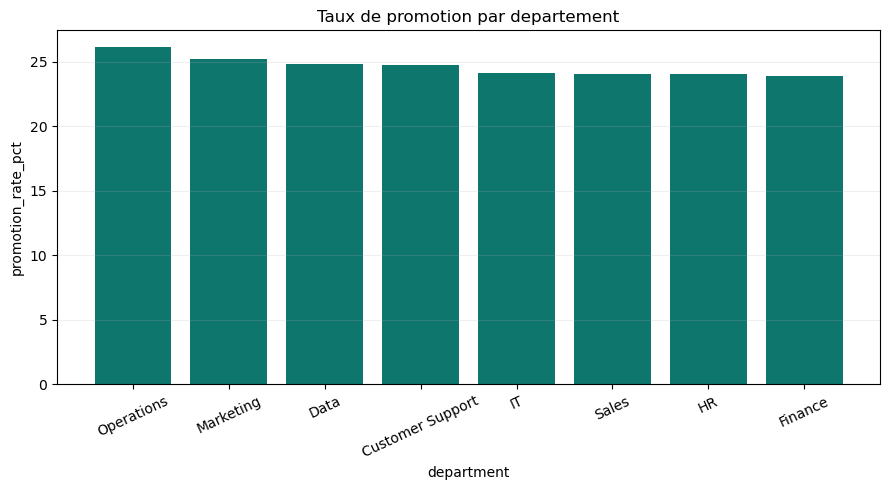

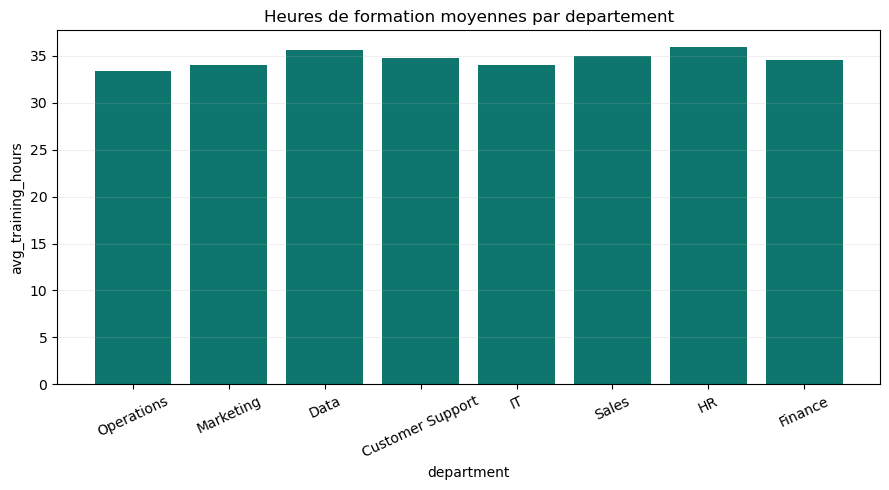

In [21]:
plot_bar(career_table.reset_index(), "department", "promotion_rate_pct", title="Taux de promotion par departement", rotation=25)
plot_bar(career_table.reset_index(), "department", "avg_training_hours", title="Heures de formation moyennes par departement", rotation=25)


## 5. Structure de remuneration

Cette partie permet d'ouvrir la discussion sur les niveaux de salaire, la progression par niveau hierarchique et les ecarts eventuels entre groupes.


In [22]:
salary_by_manager = average_by_group(df, "manager_level", "salary").sort_values("manager_level")
salary_by_manager


,manager_level,avg_salary
3,0,56389.98
2,1,68258.23
1,2,79530.19
0,3,92043.05


In [23]:
salary_gap_by_gender(df)


,gender,avg_salary,gap_vs_male_pct
0,Female,60723.11,-5.06
1,Male,63962.04,0.00
2,Non-Binary,62370.71,-2.49


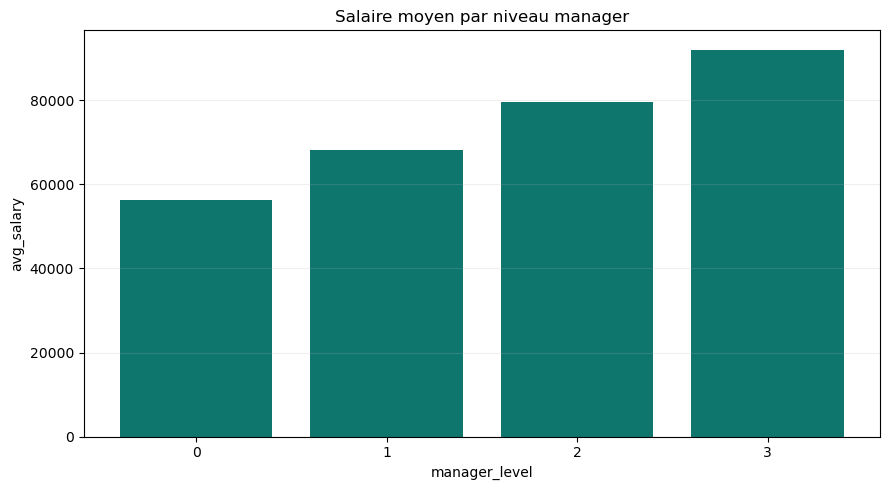

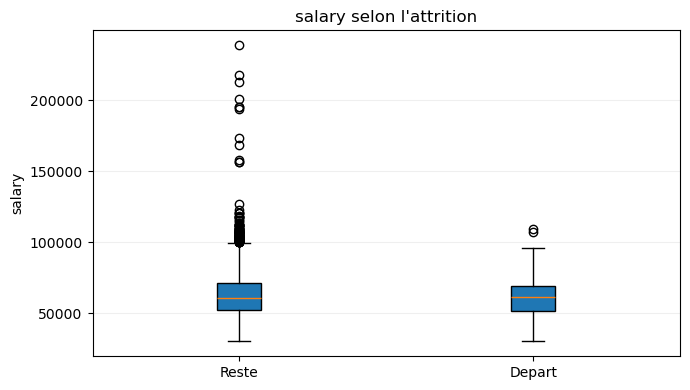

In [24]:
plot_bar(salary_by_manager, "manager_level", "avg_salary", title="Salaire moyen par niveau manager", rotation=0)
plot_box_by_attrition(df, "salary")


## 6. Mobilite interne


In [25]:
mobility_table = pd.DataFrame(
    {
        "mobility_rate_pct": df.groupby("department")["internal_mobility_count"].apply(lambda s: (s > 0).mean() * 100),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
        "attrition_rate_pct": df.groupby("department")["attrition"].mean() * 100,
    }
).round(2).sort_values("mobility_rate_pct", ascending=False)

mobility_table


,mobility_rate_pct,avg_internal_mobility,attrition_rate_pct
department,,,
IT,65.26,1.02,2.89
Customer Support,64.85,1.07,2.82
Sales,64.48,1.02,2.69
Operations,64.34,1.04,2.06
Marketing,63.68,1.02,2.57
Data,63.53,1.02,2.40
HR,62.64,0.95,2.61
Finance,60.84,0.95,2.74


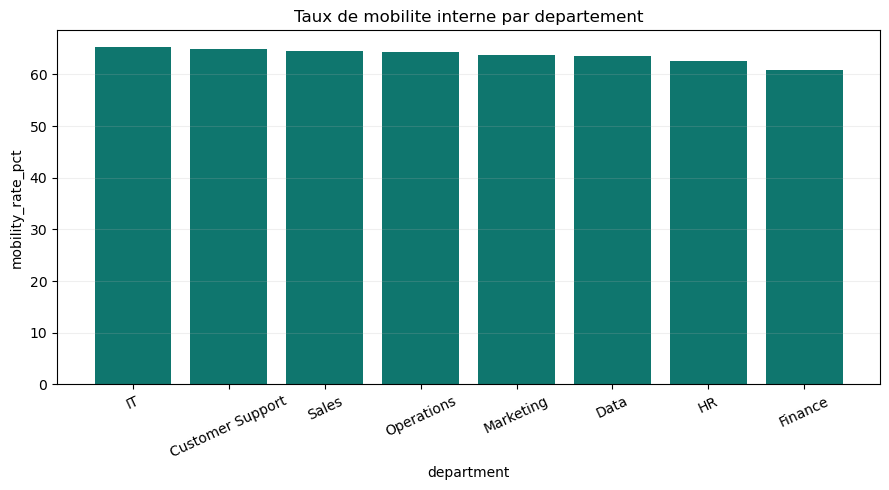

In [26]:
plot_bar(mobility_table.reset_index(), "department", "mobility_rate_pct", title="Taux de mobilite interne par departement", rotation=25)


## 7. Synthese analytique

- **Effectif** : 8 020 collaborateurs.
- **Attrition globale** : 2,59 %.
- **Engagement moyen** : 68,15 / 100.
- **Securite psychologique moyenne** : 66,19 / 100.
- **Promotion sur 3 ans** : 24,64 %.
- **Mobilite interne** : 63,72 % des collaborateurs ont connu au moins une mobilite.
- **Salaire moyen** : 62 313 par an.

### Points d'attention

- L'attrition est plus elevee en **France**, en **IT** et dans certaines populations managers de niveau 1.
- Les collaborateurs avec **engagement faible** et **fort absentisme** presentent davantage de risque de depart.
- Les collaborateurs partis ont en moyenne **moins de formation**, **un salaire plus faible** et **une securite psychologique plus basse**.
- Le salaire moyen des femmes ressort a un niveau inferieur a celui des hommes dans une lecture brute du dataset. Il faudrait prolonger par une analyse controlee des postes, pays et niveaux.
